In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Explore Dataset
Visualize the dataset and highlight the ground-truth anomalies using the provided labels.

In [2]:
# Config
# find files that follow the pattern "xxx_*.csv" in the specified directory
DATASET_DIRECTORY = Path("../datasets/TSB-AD-U")
# TODS: 293 - 300
PATTERN = "294_*.csv"
# DATASET_PATH = Path("../datasets/TSB-AD-U/001_*.csv")
FILES = list(DATASET_DIRECTORY.glob(PATTERN))
print(f"Found {len(FILES)} files matching the pattern '{PATTERN}':")
for file in FILES:
    print(f" - {file.name}")
if len(FILES) > 1:
    print("Multiple files found. Please specify the exact file to use.")
elif len(FILES) == 0:   
    print("No files found. Please check the directory and pattern.")
else:
    DATASET_PATH = FILES[0]
START_INDEX = 0#1900  # Starting point for the window
WINDOW_SIZE = 1000  # Number of samples to display

Found 1 files matching the pattern '294_*.csv':
 - 294_TODS_id_8_Synthetic_tr_500_1st_200.csv


## Plot Dataset Window

Dataset shape: (5000, 1)
Labels shape: (5000,)
Anomaly index ranges:
 - 200 to 299 (size: 100)
 - 687 to 886 (size: 200)
 - 2046 to 2055 (size: 10)
 - 2360 to 2459 (size: 100)
 - 2650 to 2659 (size: 10)
 - 2872 to 2881 (size: 10)
 - 2891 to 2900 (size: 10)
 - 3477 to 3486 (size: 10)
 - 3645 to 3654 (size: 10)
 - 3904 to 3913 (size: 10)
 - 3936 to 3945 (size: 10)
 - 4186 to 4195 (size: 10)
 - 4327 to 4336 (size: 10)
 - 4823 to 4832 (size: 10)


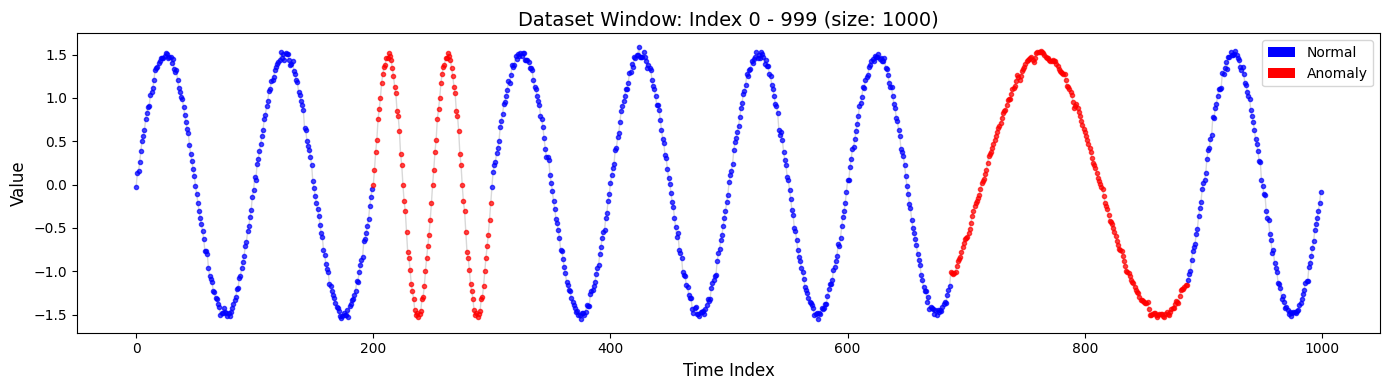

Anomalies in window: 300 / 1000


In [3]:
from matplotlib.patches import Patch
# Load dataset
df = pd.read_csv(DATASET_PATH).dropna()
data = df.iloc[:, :-1].values.astype(float)
labels = df['Label'].astype(int).to_numpy()

print(f"Dataset shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

# Print indices range of anomalies
anomaly_indices = np.where(labels == 1)[0]
# sort and combine consecutive indices into ranges
ranges = []
start = anomaly_indices[0]
for i in range(1, len(anomaly_indices)):
    if anomaly_indices[i] != anomaly_indices[i-1] + 1:
        ranges.append((start, anomaly_indices[i-1]))
        start = anomaly_indices[i]
ranges.append((start, anomaly_indices[-1]))  # add the last range
print("Anomaly index ranges:")
for start, end in ranges:
    print(f" - {start} to {end} (size: {end - start + 1})")

# Extract the window
end_index = min(START_INDEX + WINDOW_SIZE, len(data))
window_data = data[START_INDEX:end_index]
window_labels = labels[START_INDEX:end_index]
indices = np.arange(START_INDEX, end_index)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 4))

# Plot data points colored by label
for i, (idx, point) in enumerate(zip(indices, window_data)):
    color = 'red' if window_labels[i] == 1 else 'blue'
    ax.plot(idx, point, 'o', color=color, markersize=3, alpha=0.7)

# Add line connecting points for better visibility
ax.plot(indices, window_data, color='gray', alpha=0.3, linewidth=1, zorder=0)

# Add labels and legend
ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(f'Dataset Window: Index {START_INDEX} - {end_index-1} (size: {len(window_data)})', fontsize=14)

# Create custom legend
legend_elements = [
    Patch(facecolor='blue', label='Normal'),
    Patch(facecolor='red', label='Anomaly')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"Anomalies in window: {np.sum(window_labels)} / {len(window_labels)}")

Dataset pattern: 287_*TODS*.csv
Dataset file: 287_TODS_id_1_Synthetic_tr_500_1st_11.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 11 to 12 (size: 2)
 - 27 to 27 (size: 1)
 - 62 to 62 (size: 1)
 - 68 to 68 (size: 1)
 - 111 to 111 (size: 1)
 - 116 to 116 (size: 1)
 - 185 to 185 (size: 1)
 - 194 to 194 (size: 1)
 - 209 to 209 (size: 1)
 - 221 to 221 (size: 1)
 - 236 to 236 (size: 1)
 - 268 to 268 (size: 1)
 - 273 to 273 (size: 1)
 - 281 to 281 (size: 1)
 - 304 to 304 (size: 1)
 - 346 to 346 (size: 1)
 - 367 to 367 (size: 1)
 - 375 to 375 (size: 1)
 - 392 to 392 (size: 1)
 - 395 to 395 (size: 1)
 - 434 to 434 (size: 1)
 - 441 to 441 (size: 1)
 - 454 to 454 (size: 1)
 - 481 to 481 (size: 1)
 - 493 to 493 (size: 1)
 - 512 to 514 (size: 3)
 - 524 to 524 (size: 1)
 - 617 to 617 (size: 1)
 - 625 to 625 (size: 1)
 - 635 to 635 (size: 1)
 - 665 to 665 (size: 1)
 - 675 to 675 (size: 1)
 - 704 to 704 (size: 1)
 - 726 to 726 (size: 1)
 - 729 to 729 (size: 1)
 - 772 to 772 (size: 1)
 - 795 to 795 (

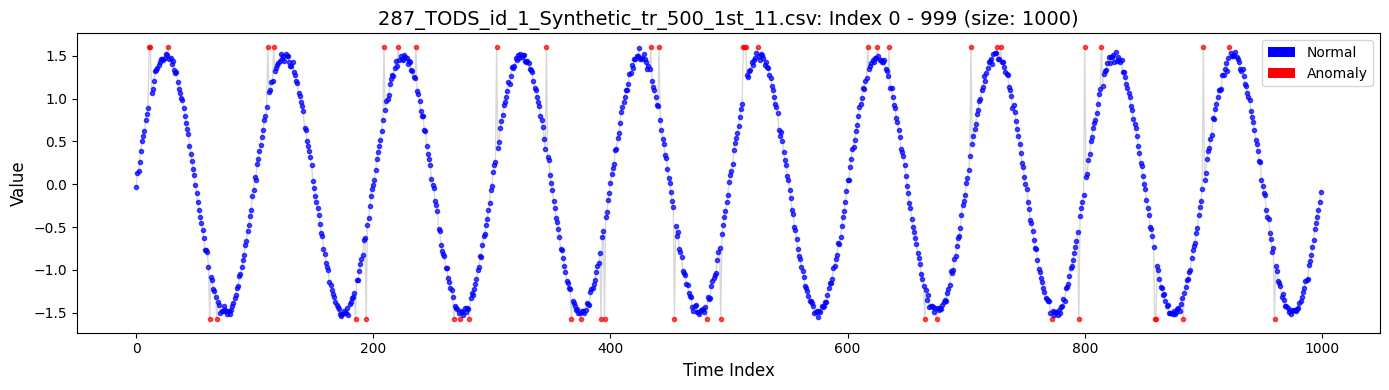

Anomalies in window: 48 / 1000

Dataset pattern: 288_*TODS*.csv
Dataset file: 288_TODS_id_2_Synthetic_tr_500_1st_65.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 65 to 65 (size: 1)
 - 71 to 71 (size: 1)
 - 77 to 77 (size: 1)
 - 129 to 129 (size: 1)
 - 187 to 187 (size: 1)
 - 198 to 198 (size: 1)
 - 217 to 217 (size: 1)
 - 250 to 250 (size: 1)
 - 397 to 397 (size: 1)
 - 407 to 407 (size: 1)
 - 411 to 411 (size: 1)
 - 413 to 413 (size: 1)
 - 418 to 418 (size: 1)
 - 434 to 434 (size: 1)
 - 440 to 440 (size: 1)
 - 524 to 524 (size: 1)
 - 601 to 601 (size: 1)
 - 650 to 650 (size: 1)
 - 731 to 731 (size: 1)
 - 787 to 787 (size: 1)
 - 807 to 807 (size: 1)
 - 821 to 821 (size: 1)
 - 836 to 836 (size: 1)
 - 839 to 839 (size: 1)
 - 842 to 842 (size: 1)
 - 871 to 871 (size: 1)
 - 886 to 886 (size: 1)
 - 898 to 898 (size: 1)
 - 1057 to 1057 (size: 1)
 - 1082 to 1082 (size: 1)
 - 1136 to 1136 (size: 1)
 - 1139 to 1139 (size: 1)
 - 1191 to 1191 (size: 1)
 - 1316 to 1316 (size: 1)
 - 1514 to 1514 (

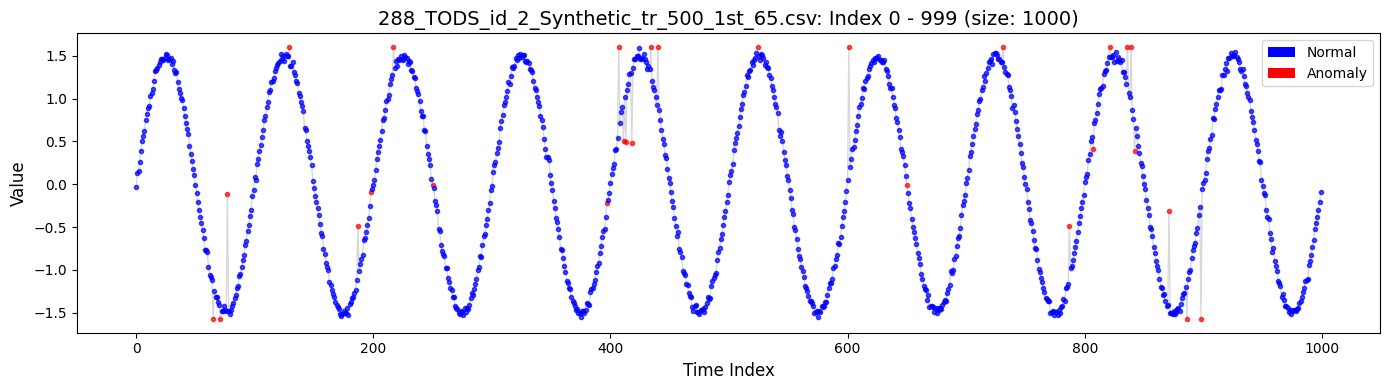

Anomalies in window: 28 / 1000

Dataset pattern: 289_*TODS*.csv
Dataset file: 289_TODS_id_3_Synthetic_tr_500_1st_26.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 26 to 26 (size: 1)
 - 61 to 61 (size: 1)
 - 77 to 78 (size: 2)
 - 104 to 104 (size: 1)
 - 187 to 187 (size: 1)
 - 198 to 198 (size: 1)
 - 205 to 205 (size: 1)
 - 250 to 250 (size: 1)
 - 271 to 271 (size: 1)
 - 313 to 313 (size: 1)
 - 347 to 347 (size: 1)
 - 397 to 397 (size: 1)
 - 411 to 411 (size: 1)
 - 413 to 413 (size: 1)
 - 418 to 418 (size: 1)
 - 517 to 517 (size: 1)
 - 725 to 725 (size: 1)
 - 746 to 746 (size: 1)
 - 787 to 787 (size: 1)
 - 807 to 807 (size: 1)
 - 864 to 864 (size: 1)
 - 871 to 871 (size: 1)
 - 956 to 956 (size: 1)
 - 1057 to 1057 (size: 1)
 - 1082 to 1082 (size: 1)
 - 1089 to 1089 (size: 1)
 - 1113 to 1113 (size: 1)
 - 1136 to 1136 (size: 1)
 - 1219 to 1219 (size: 1)
 - 1296 to 1296 (size: 1)
 - 1347 to 1347 (size: 1)
 - 1391 to 1391 (size: 1)
 - 1450 to 1450 (size: 1)
 - 1612 to 1612 (size: 1)
 - 1629

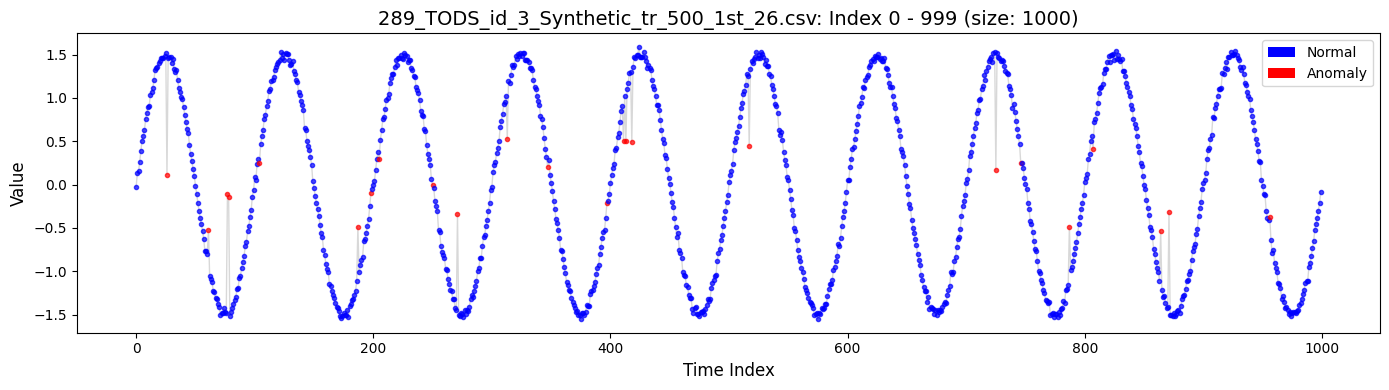

Anomalies in window: 24 / 1000

Dataset pattern: 290_*TODS*.csv
Dataset file: 290_TODS_id_4_Synthetic_tr_500_1st_26.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 26 to 26 (size: 1)
 - 77 to 77 (size: 1)
 - 187 to 187 (size: 1)
 - 198 to 198 (size: 1)
 - 205 to 205 (size: 1)
 - 250 to 250 (size: 1)
 - 271 to 271 (size: 1)
 - 347 to 347 (size: 1)
 - 397 to 397 (size: 1)
 - 411 to 411 (size: 1)
 - 413 to 413 (size: 1)
 - 418 to 418 (size: 1)
 - 517 to 517 (size: 1)
 - 650 to 650 (size: 1)
 - 787 to 787 (size: 1)
 - 807 to 807 (size: 1)
 - 864 to 864 (size: 1)
 - 871 to 871 (size: 1)
 - 1057 to 1057 (size: 1)
 - 1082 to 1082 (size: 1)
 - 1113 to 1113 (size: 1)
 - 1136 to 1136 (size: 1)
 - 1391 to 1391 (size: 1)
 - 1612 to 1612 (size: 1)
 - 1629 to 1629 (size: 1)
 - 1689 to 1788 (size: 100)
 - 1849 to 1849 (size: 1)
 - 1875 to 1875 (size: 1)
 - 1977 to 2176 (size: 200)
 - 2275 to 2275 (size: 1)
 - 2332 to 2332 (size: 1)
 - 2410 to 2410 (size: 1)
 - 2440 to 2441 (size: 2)
 - 2507 to 2507 (

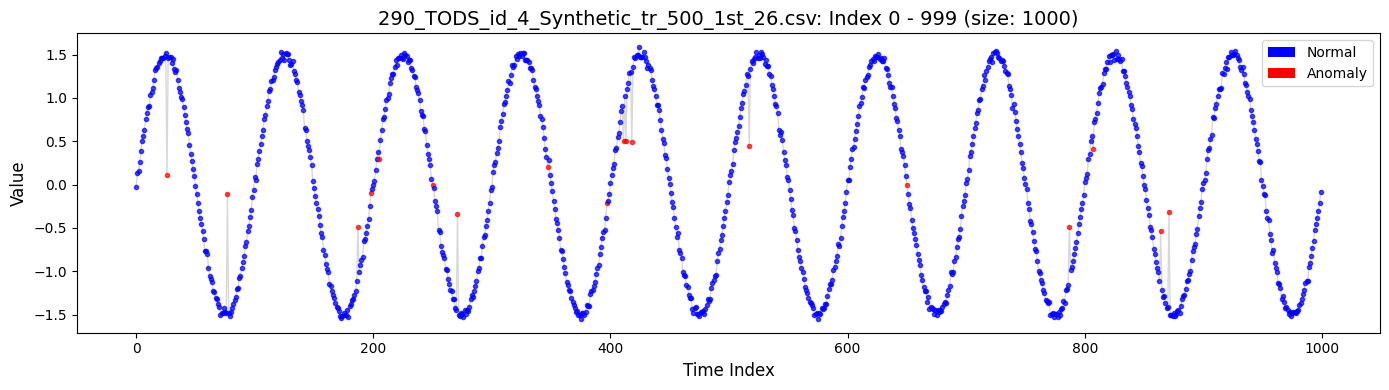

Anomalies in window: 18 / 1000

Dataset pattern: 291_*TODS*.csv
Dataset file: 291_TODS_id_5_Synthetic_tr_500_1st_11.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 11 to 12 (size: 2)
 - 27 to 27 (size: 1)
 - 62 to 62 (size: 1)
 - 68 to 68 (size: 1)
 - 111 to 111 (size: 1)
 - 116 to 116 (size: 1)
 - 185 to 185 (size: 1)
 - 194 to 194 (size: 1)
 - 209 to 209 (size: 1)
 - 221 to 221 (size: 1)
 - 236 to 236 (size: 1)
 - 268 to 268 (size: 1)
 - 273 to 273 (size: 1)
 - 281 to 281 (size: 1)
 - 304 to 304 (size: 1)
 - 346 to 346 (size: 1)
 - 367 to 367 (size: 1)
 - 375 to 375 (size: 1)
 - 392 to 392 (size: 1)
 - 395 to 395 (size: 1)
 - 434 to 434 (size: 1)
 - 441 to 441 (size: 1)
 - 454 to 454 (size: 1)
 - 481 to 481 (size: 1)
 - 493 to 493 (size: 1)
 - 512 to 514 (size: 3)
 - 524 to 524 (size: 1)
 - 617 to 617 (size: 1)
 - 625 to 625 (size: 1)
 - 635 to 635 (size: 1)
 - 665 to 665 (size: 1)
 - 675 to 675 (size: 1)
 - 704 to 704 (size: 1)
 - 726 to 726 (size: 1)
 - 729 to 729 (size: 1)
 - 772 

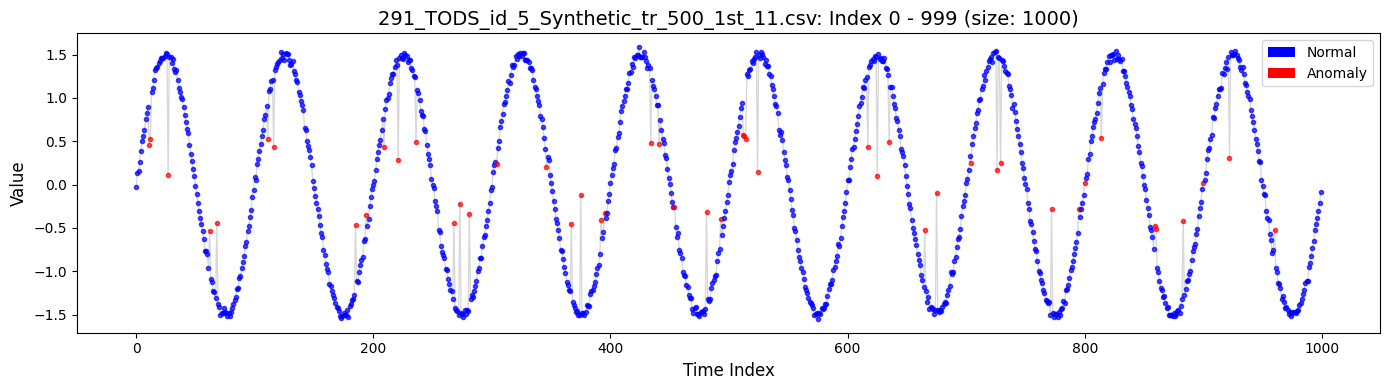

Anomalies in window: 48 / 1000

Dataset pattern: 292_*TODS*.csv
Dataset file: 292_TODS_id_6_Synthetic_tr_500_1st_11.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 11 to 12 (size: 2)
 - 27 to 27 (size: 1)
 - 62 to 62 (size: 1)
 - 68 to 68 (size: 1)
 - 111 to 111 (size: 1)
 - 116 to 116 (size: 1)
 - 185 to 185 (size: 1)
 - 194 to 194 (size: 1)
 - 209 to 209 (size: 1)
 - 221 to 221 (size: 1)
 - 236 to 236 (size: 1)
 - 268 to 268 (size: 1)
 - 273 to 273 (size: 1)
 - 281 to 281 (size: 1)
 - 304 to 304 (size: 1)
 - 346 to 346 (size: 1)
 - 367 to 367 (size: 1)
 - 375 to 375 (size: 1)
 - 392 to 392 (size: 1)
 - 395 to 395 (size: 1)
 - 434 to 434 (size: 1)
 - 441 to 441 (size: 1)
 - 454 to 454 (size: 1)
 - 481 to 481 (size: 1)
 - 493 to 493 (size: 1)
 - 512 to 514 (size: 3)
 - 524 to 524 (size: 1)
 - 617 to 617 (size: 1)
 - 625 to 625 (size: 1)
 - 635 to 635 (size: 1)
 - 665 to 665 (size: 1)
 - 675 to 675 (size: 1)
 - 704 to 704 (size: 1)
 - 726 to 726 (size: 1)
 - 729 to 729 (size: 1)
 - 772 

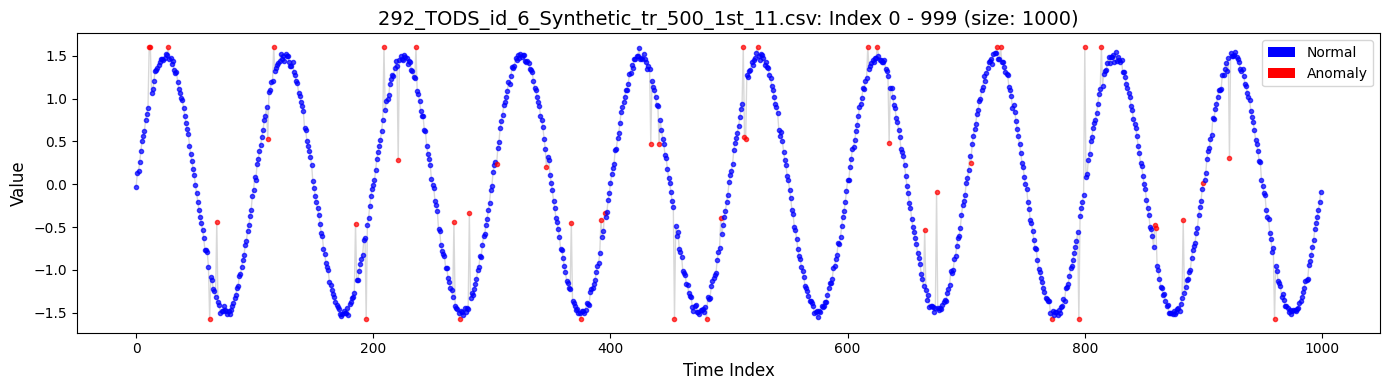

Anomalies in window: 48 / 1000

Dataset pattern: 293_*TODS*.csv
Dataset file: 293_TODS_id_7_Synthetic_tr_500_1st_7.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 7 to 16 (size: 10)
 - 519 to 528 (size: 10)
 - 809 to 818 (size: 10)
 - 1214 to 1223 (size: 10)
 - 1695 to 1704 (size: 10)
 - 1798 to 1807 (size: 10)
 - 2046 to 2055 (size: 10)
 - 2115 to 2124 (size: 10)
 - 2650 to 2659 (size: 10)
 - 2872 to 2881 (size: 10)
 - 2891 to 2900 (size: 10)
 - 3339 to 3348 (size: 10)
 - 3423 to 3438 (size: 16)
 - 3477 to 3486 (size: 10)
 - 3645 to 3654 (size: 10)
 - 3709 to 3718 (size: 10)
 - 3899 to 3913 (size: 15)
 - 3936 to 3945 (size: 10)
 - 4186 to 4195 (size: 10)
 - 4270 to 4279 (size: 10)
 - 4293 to 4302 (size: 10)
 - 4327 to 4336 (size: 10)
 - 4823 to 4832 (size: 10)
 - 4949 to 4958 (size: 10)


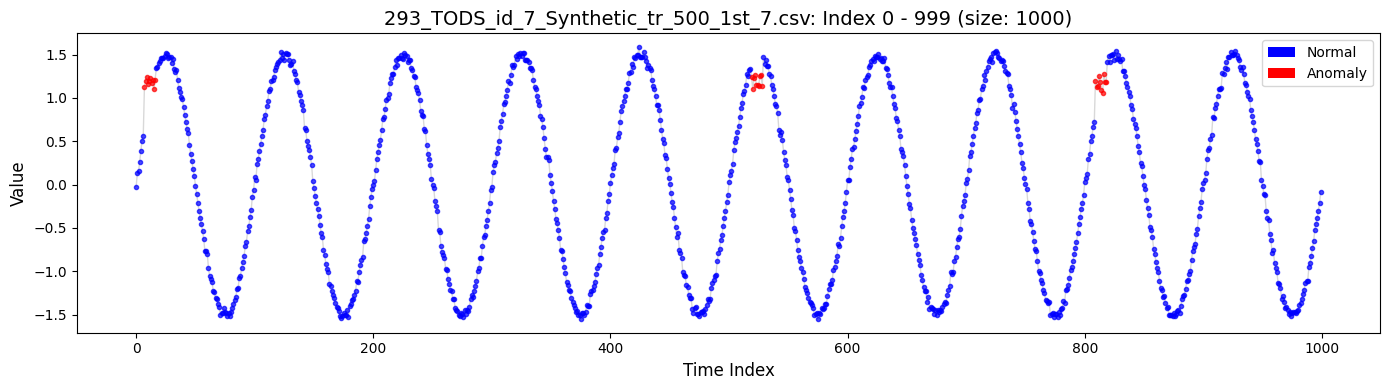

Anomalies in window: 30 / 1000

Dataset pattern: 294_*TODS*.csv
Dataset file: 294_TODS_id_8_Synthetic_tr_500_1st_200.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 200 to 299 (size: 100)
 - 687 to 886 (size: 200)
 - 2046 to 2055 (size: 10)
 - 2360 to 2459 (size: 100)
 - 2650 to 2659 (size: 10)
 - 2872 to 2881 (size: 10)
 - 2891 to 2900 (size: 10)
 - 3477 to 3486 (size: 10)
 - 3645 to 3654 (size: 10)
 - 3904 to 3913 (size: 10)
 - 3936 to 3945 (size: 10)
 - 4186 to 4195 (size: 10)
 - 4327 to 4336 (size: 10)
 - 4823 to 4832 (size: 10)


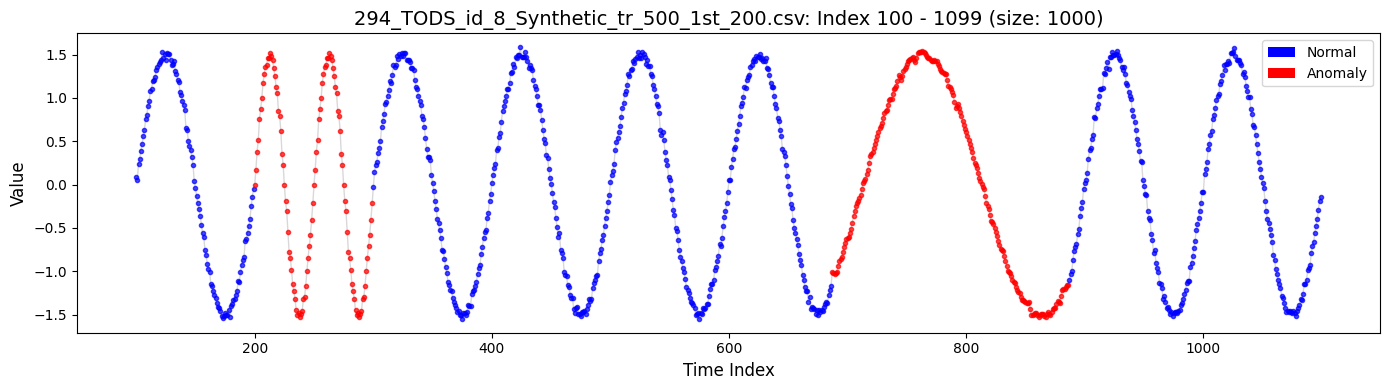

Anomalies in window: 300 / 1000

Dataset pattern: 295_*TODS*.csv
Dataset file: 295_TODS_id_9_Synthetic_tr_1250_1st_2046.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 2046 to 2055 (size: 10)
 - 2650 to 2659 (size: 10)
 - 2872 to 2881 (size: 10)
 - 2891 to 2900 (size: 10)
 - 3477 to 3486 (size: 10)
 - 3600 to 3699 (size: 100)
 - 3904 to 3913 (size: 10)
 - 3936 to 3945 (size: 10)
 - 4186 to 4195 (size: 10)
 - 4232 to 4431 (size: 200)
 - 4823 to 4832 (size: 10)


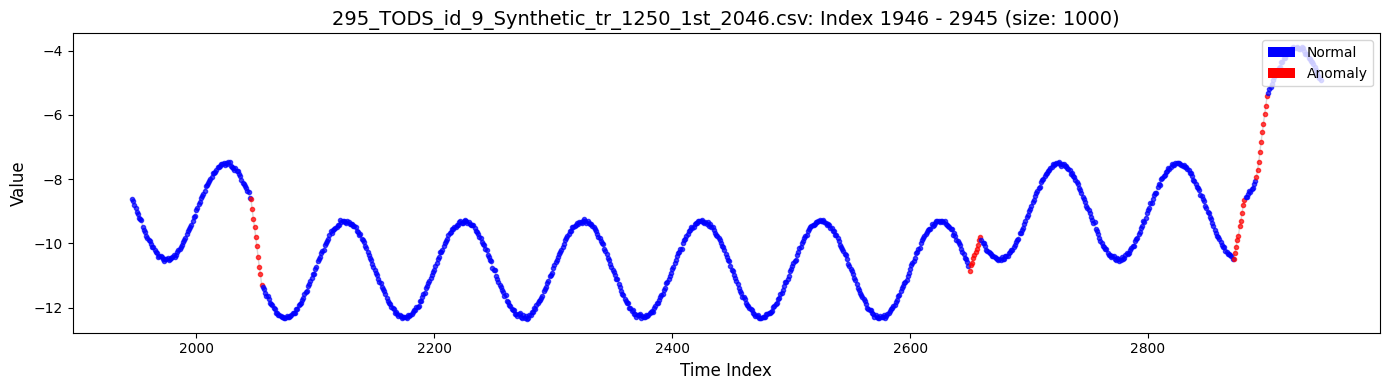

Anomalies in window: 40 / 1000

Dataset pattern: 296_*TODS*.csv
Dataset file: 296_TODS_id_10_Synthetic_tr_500_1st_26.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 26 to 26 (size: 1)
 - 61 to 61 (size: 1)
 - 77 to 78 (size: 2)
 - 104 to 104 (size: 1)
 - 162 to 162 (size: 1)
 - 187 to 187 (size: 1)
 - 198 to 198 (size: 1)
 - 205 to 205 (size: 1)
 - 229 to 229 (size: 1)
 - 250 to 250 (size: 1)
 - 271 to 271 (size: 1)
 - 313 to 313 (size: 1)
 - 347 to 347 (size: 1)
 - 353 to 353 (size: 1)
 - 390 to 390 (size: 1)
 - 397 to 397 (size: 1)
 - 400 to 400 (size: 1)
 - 411 to 411 (size: 1)
 - 413 to 413 (size: 1)
 - 418 to 418 (size: 1)
 - 517 to 517 (size: 1)
 - 620 to 620 (size: 1)
 - 650 to 650 (size: 1)
 - 725 to 725 (size: 1)
 - 746 to 746 (size: 1)
 - 787 to 787 (size: 1)
 - 807 to 807 (size: 1)
 - 828 to 828 (size: 1)
 - 864 to 864 (size: 1)
 - 871 to 871 (size: 1)
 - 956 to 956 (size: 1)
 - 987 to 987 (size: 1)
 - 1028 to 1028 (size: 1)
 - 1057 to 1057 (size: 1)
 - 1082 to 1082 (size: 1

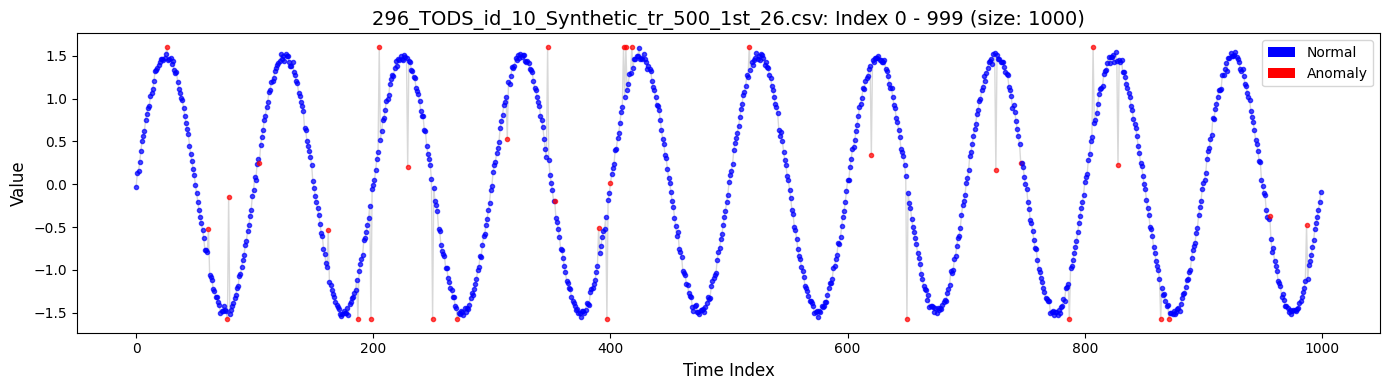

Anomalies in window: 33 / 1000

Dataset pattern: 297_*TODS*.csv
Dataset file: 297_TODS_id_11_Synthetic_tr_500_1st_7.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 7 to 16 (size: 10)
 - 519 to 528 (size: 10)
 - 809 to 818 (size: 10)
 - 1214 to 1223 (size: 10)
 - 1695 to 1704 (size: 10)
 - 1798 to 1807 (size: 10)
 - 2046 to 2055 (size: 10)
 - 2115 to 2124 (size: 10)
 - 2650 to 2659 (size: 10)
 - 2872 to 2881 (size: 10)
 - 2891 to 2900 (size: 10)
 - 3339 to 3348 (size: 10)
 - 3423 to 3438 (size: 16)
 - 3477 to 3486 (size: 10)
 - 3645 to 3654 (size: 10)
 - 3709 to 3718 (size: 10)
 - 3899 to 3913 (size: 15)
 - 3936 to 3945 (size: 10)
 - 4186 to 4195 (size: 10)
 - 4270 to 4279 (size: 10)
 - 4293 to 4302 (size: 10)
 - 4327 to 4336 (size: 10)
 - 4823 to 4832 (size: 10)
 - 4949 to 4958 (size: 10)


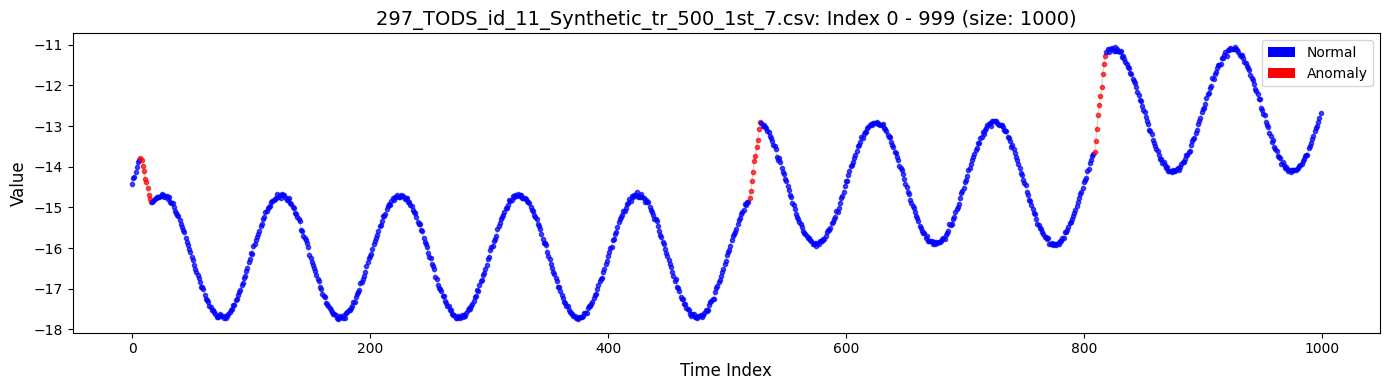

Anomalies in window: 30 / 1000

Dataset pattern: 298_*TODS*.csv
Dataset file: 298_TODS_id_12_Synthetic_tr_500_1st_0.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 0 to 1 (size: 2)
 - 65 to 65 (size: 1)
 - 71 to 71 (size: 1)
 - 124 to 133 (size: 10)
 - 217 to 217 (size: 1)
 - 407 to 407 (size: 1)
 - 434 to 444 (size: 11)
 - 524 to 524 (size: 1)
 - 601 to 601 (size: 1)
 - 731 to 731 (size: 1)
 - 821 to 821 (size: 1)
 - 836 to 836 (size: 1)
 - 842 to 842 (size: 1)
 - 881 to 890 (size: 10)
 - 1139 to 1139 (size: 1)
 - 1316 to 1316 (size: 1)
 - 1514 to 1514 (size: 1)
 - 1531 to 1531 (size: 1)
 - 1553 to 1553 (size: 1)
 - 1582 to 1582 (size: 1)
 - 1657 to 1657 (size: 1)
 - 1739 to 1739 (size: 1)
 - 1828 to 1828 (size: 1)
 - 2048 to 2048 (size: 1)
 - 2077 to 2077 (size: 1)
 - 2301 to 2301 (size: 1)
 - 2338 to 2338 (size: 1)
 - 2344 to 2344 (size: 1)
 - 2350 to 2359 (size: 10)
 - 2455 to 2455 (size: 1)
 - 2492 to 2492 (size: 1)
 - 2512 to 2512 (size: 1)
 - 2528 to 2528 (size: 1)
 - 2532 to 25

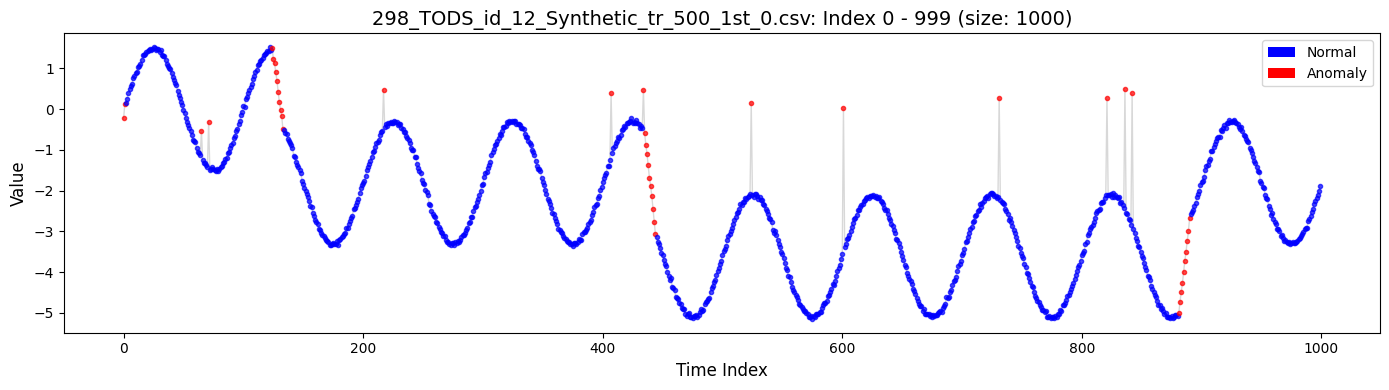

Anomalies in window: 43 / 1000

Dataset pattern: 299_*TODS*.csv
Dataset file: 299_TODS_id_13_Synthetic_tr_500_1st_65.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 65 to 65 (size: 1)
 - 71 to 71 (size: 1)
 - 77 to 77 (size: 1)
 - 124 to 133 (size: 10)
 - 187 to 187 (size: 1)
 - 198 to 198 (size: 1)
 - 217 to 217 (size: 1)
 - 250 to 250 (size: 1)
 - 397 to 397 (size: 1)
 - 407 to 407 (size: 1)
 - 413 to 413 (size: 1)
 - 434 to 444 (size: 11)
 - 524 to 524 (size: 1)
 - 601 to 601 (size: 1)
 - 650 to 650 (size: 1)
 - 731 to 731 (size: 1)
 - 762 to 771 (size: 10)
 - 787 to 787 (size: 1)
 - 807 to 807 (size: 1)
 - 821 to 821 (size: 1)
 - 836 to 836 (size: 1)
 - 839 to 839 (size: 1)
 - 842 to 842 (size: 1)
 - 871 to 871 (size: 1)
 - 898 to 898 (size: 1)
 - 1057 to 1057 (size: 1)
 - 1082 to 1082 (size: 1)
 - 1139 to 1139 (size: 1)
 - 1191 to 1191 (size: 1)
 - 1316 to 1316 (size: 1)
 - 1514 to 1514 (size: 1)
 - 1531 to 1531 (size: 1)
 - 1553 to 1553 (size: 1)
 - 1582 to 1582 (size: 1)
 - 1657

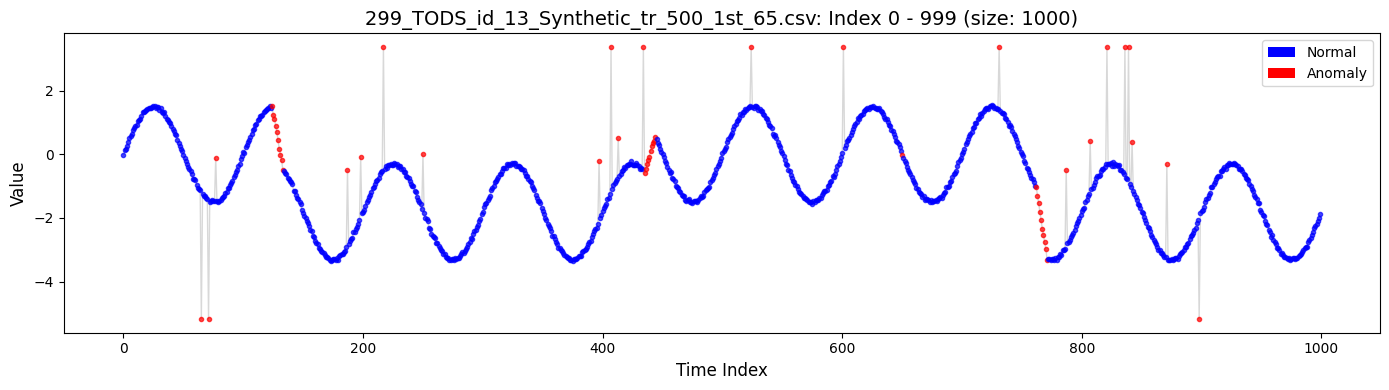

Anomalies in window: 53 / 1000

Dataset pattern: 300_*TODS*.csv
Dataset file: 300_TODS_id_14_Synthetic_tr_1250_1st_2555.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 2555 to 2754 (size: 200)
 - 3600 to 3699 (size: 100)
 - 4282 to 4381 (size: 100)


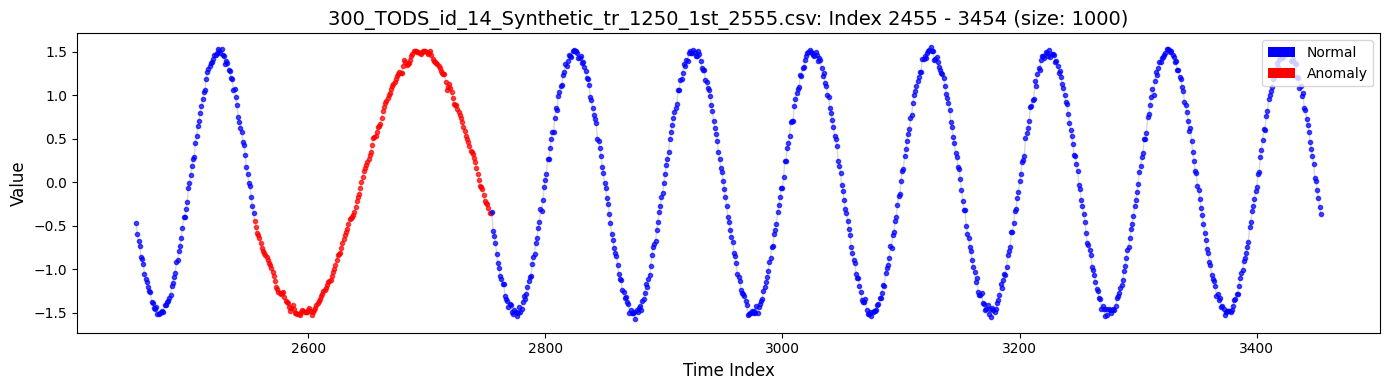

Anomalies in window: 200 / 1000

Dataset pattern: 301_*TODS*.csv
Dataset file: 301_TODS_id_15_Synthetic_tr_500_1st_245.csv
Dataset shape: (5000, 1)
Anomaly ranges:
 - 245 to 254 (size: 10)
 - 645 to 654 (size: 10)
 - 782 to 791 (size: 10)
 - 1689 to 1788 (size: 100)
 - 1977 to 2176 (size: 200)
 - 2405 to 2414 (size: 10)
 - 2650 to 2659 (size: 10)
 - 3269 to 3278 (size: 10)
 - 3645 to 3654 (size: 10)
 - 3904 to 3913 (size: 10)
 - 3936 to 3945 (size: 10)
 - 3979 to 3988 (size: 10)
 - 4327 to 4336 (size: 10)


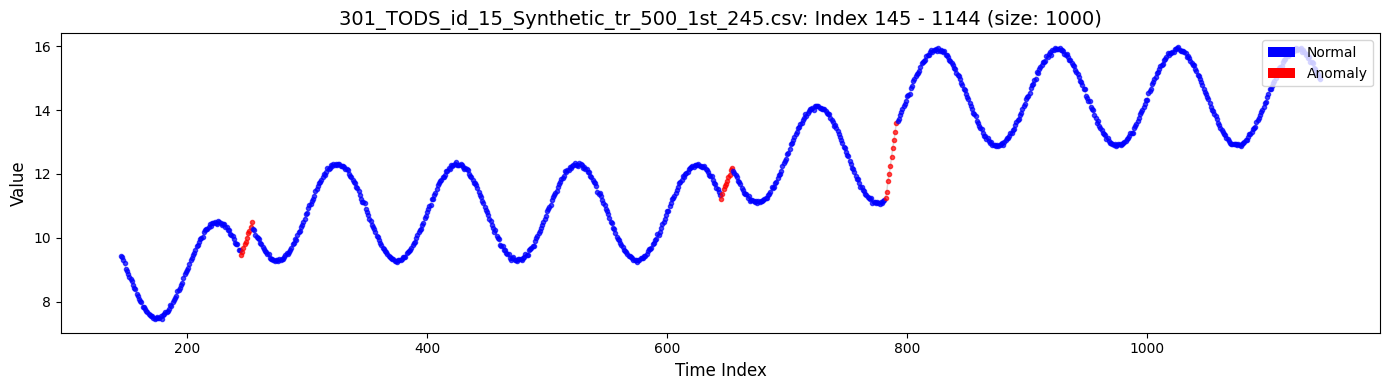

Anomalies in window: 30 / 1000



In [7]:
from matplotlib.patches import Patch

DS_START_INDEX = 0
DS_WINDOW_SIZE = 1000
DATASET_NAME = "TODS"
# DATASET_NAME = "Stock"
DATASET_IDS = sorted({int(file.name.split('_')[0]) for file in DATASET_DIRECTORY.glob(f'*{DATASET_NAME}*.csv')})

for dataset_id in DATASET_IDS:
    pattern = f"{dataset_id}_*{DATASET_NAME}*.csv"
    files = list(DATASET_DIRECTORY.glob(pattern))

    print("=" * 100)
    print(f"Dataset pattern: {pattern}")

    if len(files) == 0:
        print("No files found. Please check the directory and pattern.")
        continue
    if len(files) > 1:
        print("Multiple files found. Please specify the exact file to use.")
        for file in files:
            print(f" - {file.name}")
        continue

    dataset_path = files[0]
    print(f"Dataset file: {dataset_path.name}")

    df = pd.read_csv(dataset_path).dropna()
    data = df.iloc[:, :-1].values.astype(float)
    labels = df['Label'].astype(int).to_numpy()

    print(f"Dataset shape: {data.shape}")
    # print(f"Labels shape: {labels.shape}")

    anomaly_indices = np.where(labels == 1)[0]
    print("Anomaly ranges:")
    if len(anomaly_indices) == 0:
        print(" - No anomalies found")
    else:
        # set start index to first occurrence of anomaly
        DS_START_INDEX = anomaly_indices[0] - 100 if anomaly_indices[0] >= 100 else 0
        ranges = []
        start = anomaly_indices[0]
        for i in range(1, len(anomaly_indices)):
            if anomaly_indices[i] != anomaly_indices[i - 1] + 1:
                ranges.append((start, anomaly_indices[i - 1]))
                start = anomaly_indices[i]
        ranges.append((start, anomaly_indices[-1]))
        for start, end in ranges:
            print(f" - {start} to {end} (size: {end - start + 1})")

    end_index = min(DS_START_INDEX + DS_WINDOW_SIZE, len(data))
    window_data = data[DS_START_INDEX:end_index]
    window_labels = labels[DS_START_INDEX:end_index]
    indices = np.arange(DS_START_INDEX, end_index)

    fig, ax = plt.subplots(figsize=(14, 4))

    for i, (idx, point) in enumerate(zip(indices, window_data)):
        color = 'red' if window_labels[i] == 1 else 'blue'
        ax.plot(idx, point, 'o', color=color, markersize=3, alpha=0.7)

    ax.plot(indices, window_data, color='gray', alpha=0.3, linewidth=1, zorder=0)

    ax.set_xlabel('Time Index', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(
        f'{dataset_path.name}: Index {DS_START_INDEX} - {end_index - 1} '
        f'(size: {len(window_data)})',
        fontsize=14,
    )

    legend_elements = [
        Patch(facecolor='blue', label='Normal'),
        Patch(facecolor='red', label='Anomaly')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

    print(f"Anomalies in window: {np.sum(window_labels)} / {len(window_labels)}")
    print()